In [2]:
import matplotlib.pyplot as plt 
import numpy as np 
import pandas as pd 
import yfinance as yf 
import statsmodels.api as sm 
from statsmodels.tsa.stattools import adfuller 
from datetime import date



In [3]:
tickers = ["GLD", "SLV"]
data = yf.download(tickers, start="2001-01-01", end=date.today().strftime("%Y-%m-%d"))
data.head()

[*********************100%***********************]  2 of 2 completed


Price           Close           High            Low           Open      \
Ticker            GLD SLV        GLD SLV        GLD SLV        GLD SLV   
Date                                                                     
2004-11-18  44.380001 NaN  44.490002 NaN  44.070000 NaN  44.430000 NaN   
2004-11-19  44.779999 NaN  44.919998 NaN  44.470001 NaN  44.490002 NaN   
2004-11-22  44.950001 NaN  44.970001 NaN  44.740002 NaN  44.750000 NaN   
2004-11-23  44.750000 NaN  44.919998 NaN  44.720001 NaN  44.880001 NaN   
2004-11-24  45.049999 NaN  45.049999 NaN  44.790001 NaN  44.930000 NaN   

Price         Volume      
Ticker           GLD SLV  
Date                      
2004-11-18   5992000 NaN  
2004-11-19  11655300 NaN  
2004-11-22  11996000 NaN  
2004-11-23   3169200 NaN  
2004-11-24   6105100 NaN

In [4]:
data = data.dropna()

#close_df = data.loc[:, 'Close']
df = data.loc[:, 'Close']
gold = df["GLD"]
silver = df["SLV"]

In [5]:
# --- STEP 1: Linear Regression to find the Hedge Ratio ---
# We model: Silver = beta * Gold + alpha + epsilon
X = sm.add_constant(gold)  # Adds a constant term (alpha) to the predictor
model = sm.OLS(silver, X).fit()

In [6]:
alpha = model.params["const"]
beta = model.params["GLD"]
print("\n--- Step 1: Regression Results ---")
print(f"Hedge Ratio (Beta): {beta:.4f}")
print(f"Intercept (Alpha): {alpha:.4f}")


--- Step 1: Regression Results ---
Hedge Ratio (Beta): 0.1320
Intercept (Alpha): 1.8089


In [7]:
# --- STEP 2: Isolate the Spread and Run the ADF Test ---
# Calculate the residuals (epsilon), which represent our spread
spread = silver - (beta * gold + alpha)
spread

Date
2006-04-28    3.414226
2006-05-01    3.462987
2006-05-02    3.774571
2006-05-03    3.346447
2006-05-04    3.286853
                ...   
2026-06-16    9.112066
2026-06-17    7.523616
2026-06-18    6.618908
2026-06-22    6.352754
2026-06-23    4.132062
Length: 5069, dtype: float64

In [8]:
# Run the Augmented Dickey-Fuller test on the spread
adf_result = adfuller(spread, maxlag=1)

In [9]:
# Extract key statistics
adf_statistic = adf_result[0]
p_value = adf_result[1]
critical_values = adf_result[4]

In [10]:
print("\n--- Step 2: Augmented Dickey-Fuller (ADF) Test ---")
print(f"ADF Statistic: {adf_statistic:.4f}")
print(f"p-value: {p_value:.4f}")
print("Critical Values:")
for key, val in critical_values.items():
    print(f"   {key}: {val:.4f}")


--- Step 2: Augmented Dickey-Fuller (ADF) Test ---
ADF Statistic: -3.9533
p-value: 0.0017
Critical Values:
   1%: -3.4316
   5%: -2.8621
   10%: -2.5671


In [11]:
# --- Interpretation ---
print("\n--- Conclusion ---")
if p_value < 0.05:
    print(
        f"Reject H0 (p = {p_value:.4f} < 0.05): The spread is stationary."
    )
    print("Gold and Silver are statistically COINTEGRATED. The leash holds!")
else:
    print(
        f"Fail to reject H0 (p = {p_value:.4f} >= 0.05): The spread has a random walk."
    )
    print("Gold and Silver are NOT cointegrated over this period.")


--- Conclusion ---
Reject H0 (p = 0.0017 < 0.05): The spread is stationary.
Gold and Silver are statistically COINTEGRATED. The leash holds!


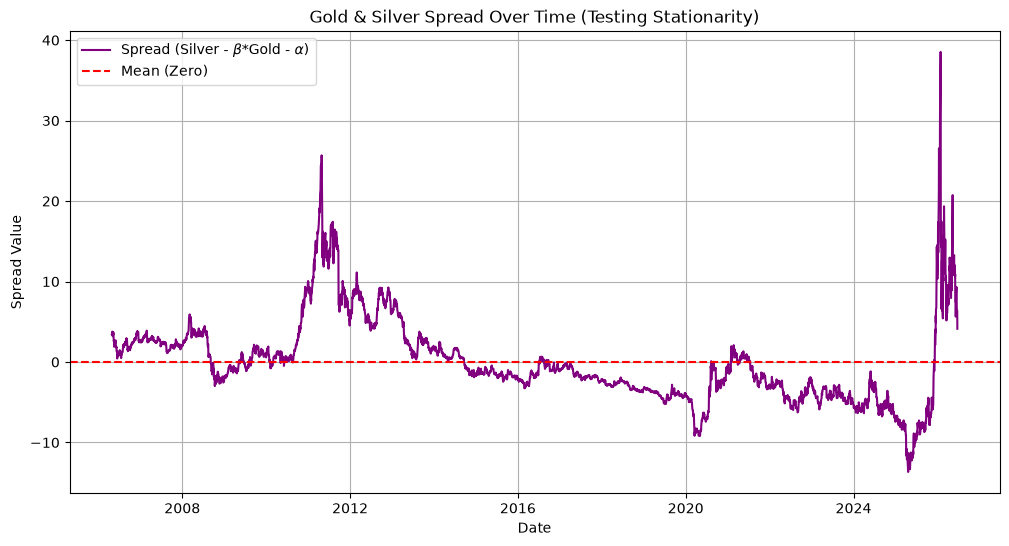

In [12]:
# --- Visualizing the Spread ---
plt.figure(figsize=(12, 6))
plt.plot(spread, label="Spread (Silver - $\\beta$*Gold - $\\alpha$)", color="purple")
plt.axhline(spread.mean(), color="red", linestyle="--", label="Mean (Zero)")
plt.title("Gold & Silver Spread Over Time (Testing Stationarity)")
plt.xlabel("Date")
plt.ylabel("Spread Value")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
# half time 

lagged_spread = spread.shift(1)

# step 2 : 
delta_spread = spread.diff()

df_ou = pd.DataFrame({"delta": delta_spread, "lagged": lagged_spread}).dropna()

# Step 4: Regress delta_spread on lagged_spread (plus a constant alpha)
X_ou = sm.add_constant(df_ou["lagged"])
model_ou = sm.OLS(df_ou["delta"], X_ou).fit()



# Extract the beta coefficient (slope of the lagged spread)
beta_ou = model_ou.params["lagged"]

print("--- Ornstein-Uhlenbeck Process Results ---")
print(f"Beta (Mean Reversion Speed): {beta_ou:.4f}")



--- Ornstein-Uhlenbeck Process Results ---
Beta (Mean Reversion Speed): -0.0062


In [14]:
# Step 5: Calculate Half-Life
if beta_ou < 0:
    half_life = -np.log(2) / np.log(1 + beta_ou)
    print(f"Half-Life of Mean Reversion: {half_life:.2f} days")
else:
    print(
        f"Half-Life is infinite or undefined (Beta is positive: {beta_ou:.4f})."
    )
    print("The spread is diverging rather than mean-reverting.")

Half-Life of Mean Reversion: 112.00 days


In [15]:
# Assuming 'spread' is the 25-year series you calculated from your data

# Define a rolling window (e.g., 252 trading days = 1 year)
window = 252
rolling_half_lives = []

# Loop through the data to calculate half-life over a moving 1-year window
for i in range(window, len(spread)):
    # Slice the current 1-year window of the spread
    window_spread = spread.iloc[i - window : i]

    lagged = window_spread.shift(1)
    delta = window_spread.diff()

    df_ou = pd.DataFrame({"delta": delta, "lagged": lagged}).dropna()

    X = sm.add_constant(df_ou["lagged"])
    model = sm.OLS(df_ou["delta"], X).fit()
    beta = model.params["lagged"]

    # Calculate half-life if it's mean-reverting
    if beta < 0:
        hl = -np.log(2) / np.log(1 + beta)
    else:
        hl = np.nan  # Not mean-reverting in this specific year

    rolling_half_lives.append(hl)

# Convert to a Series for analysis
rolling_hl_series = pd.Series(rolling_half_lives, index=spread.index[window:])

print("\n--- Rolling Half-Life Analysis ---")
print(f"Historical Average Half-Life: {rolling_hl_series.mean():.2f} days")
print(f"Most Recent Half-Life (Current Regime): {rolling_hl_series.iloc[-1]:.2f} days")


--- Rolling Half-Life Analysis ---
Historical Average Half-Life: 67.27 days
Most Recent Half-Life (Current Regime): 27.85 days
